# Preprocessing

This notebook applies the preprocessing pipeline defined in `src/preprocessing.py`. The choices for each column come directly from the issues identified in the EDA notebook. We re-state the rationale here so the report can quote it, then show the before/after.

The full pipeline runs in one call to `build_features()`. The intermediate steps below exist for inspection rather than re-implementation.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
# Silence only the two known-noisy third-party categories rather than every
# warning: a blanket ignore hides real deprecations until they become errors.
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")
warnings.filterwarnings("ignore", message=".*force_all_finite.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import preprocessing as pp
from src import visualization as viz
from src import config as cfg

viz.set_style()
pd.set_option("display.max_columns", 60)

## 1. Loading and a final look at what needs fixing

In [2]:
raw = pp.load_customer_info()
print("Raw shape:", raw.shape)
pp.missing_report(raw)

Raw shape: (33038, 25)


,missing,pct_missing
loyalty_card_number,13106,39.67
lifetime_spend_fish,991,3.00
number_complaints,661,2.00
lifetime_spend_vegetables,661,2.00
lifetime_spend_meat,661,2.00
lifetime_spend_videogames,661,2.00
typical_hour,661,2.00
lifetime_spend_electronics,661,2.00
lifetime_spend_petfood,661,2.00
distinct_stores_visited,330,1.00


## 2. Cleaning, step by step

### 2.1 Parsing dates into age

We convert `customer_birthdate` from `MM/DD/YYYY hh:mm AM/PM` strings to a numeric age in years anchored to the project reference date.

In [3]:
step1 = pp.parse_birthdate(raw)
step1[["customer_birthdate", "age"]].head()

,customer_birthdate,age
0,02/12/1970 01:36 PM,56.260096
1,11/13/1975 06:58 PM,50.510609
2,09/10/1971 10:07 AM,54.685832
3,10/23/1982 11:20 AM,43.567420
4,08/04/1969 10:22 PM,56.785763


### 2.2 Extracting the degree from `customer_name`

The name string carries a hidden categorical feature: the academic degree prefix. Missing prefix is its own category (`"None"`) because that absence is itself informative.

In [4]:
step2 = pp.extract_degree(step1)
step2["degree"].value_counts()

degree
None    17731
Bsc      5154
Phd      5096
Msc      5057
Name: count, dtype: int64

### 2.3 Converting loyalty card to a binary flag

The numeric column carries no information because the only non-null value is 1.0. The signal lives in the presence/absence pattern.

In [5]:
step3 = pp.transform_loyalty_card(step2)
step3["has_loyalty_card"].value_counts()

has_loyalty_card
1    19932
0    13106
Name: count, dtype: int64

### 2.4 Fixing the future-year problem

Almost 3% of customers have first_transaction_year between 2027 and 2029. We cap to 2026 and derive `tenure_years` from that.

In [6]:
before = (raw["year_first_transaction"] > 2026).sum()
step4 = pp.clip_first_transaction_year(step3)
after = (step4["year_first_transaction"] > 2026).sum()
print(f"Future-year rows before: {before}, after: {after}")
step4[["year_first_transaction", "tenure_years"]].describe().round(1)

Future-year rows before: 991, after: 0


,year_first_transaction,tenure_years
count,33038.0,33038.0
mean,2015.3,10.7
std,4.9,4.9
min,1993.0,0.0
25%,2012.0,7.0
50%,2015.0,11.0
75%,2019.0,14.0
max,2026.0,33.0


### 2.5 Cap the promo percentage

Negative percentages are impossible. We cap to [0, 1].

In [7]:
before_neg = (raw["percentage_of_products_bought_promotion"] < 0).sum()
step5 = pp.clip_promo_percentage(step4)
after_neg = (step5["percentage_of_products_bought_promotion"] < 0).sum()
print(f"Negative-promo rows before: {before_neg}, after: {after_neg}")

Negative-promo rows before: 1755, after: 0


### 2.6 Imputation

Each column gets the treatment most consistent with its meaning:

- Spend columns: missing values means zero (0) spend. We fill with 0.
- Counts (kids, teens, complaints): missing most likely means none. Fill with 0.
- Continuous numerics (stores visited, typical hour, promo %): median.
- Age: median (very low missingness).
- Gender: mode.

The rationale is that a one-size-fits-all imputation strategy would distort the meaning of half these columns. A customer with no recorded spend on alcohol probably did not buy any; a customer with no recorded `distinct_stores_visited` may still have visited some, so median is safer there.

In [8]:
step6 = pp.impute_missing(step5)
after_missing = step6.isnull().sum()
print("Remaining nulls per column after imputation:")
print(after_missing[after_missing > 0])

Remaining nulls per column after imputation:
customer_birthdate       165
loyalty_card_number    13106
dtype: int64


`loyalty_card_number` still shows missing because we deliberately leave it alone — the `has_loyalty_card` flag we built earlier is what we use downstream. It is dropped, along with the per-person identifiers, in the save step at the end of this notebook.

### 2.7 Outlier handling

Two strategies, applied asymmetrically across columns:

- **Nine spend columns (everything except groceries) are capped at their 99th percentile.** This trims roughly the top 1% of each column individually, which prevents extreme buyers in any one category from dominating K-Means distance calculations. Because we cap nine columns independently, the union of affected rows is larger than 1% of customers; in practice about 8% of customers have at least one column capped.
- **`lifetime_spend_groceries` is NOT capped.** Groceries is about 69% of total spend on average and spans several orders of magnitude; capping it would compress the most informative spend axis and distort `total_spend` for the highest-value customers. Instead, groceries flows uncapped into `total_spend`, which is then `log1p`-transformed downstream (creating `total_spend_log`). Logging the total handles the grocery-driven skew without a hard cap.
- **`kids_home` and `teens_home` are capped at 4** to control the very long tails.

* about shares.* Shares are computed AFTER capping (i.e. each `share_x = capped_x / sum(capped_x)`), so they still sum exactly to 1 per customer. The asymmetry ( groceries uncapped, the other nine capped ), slightly inflates the relative share of capped categories for the ~8% of customers whose categories were capped, because their numerator is unchanged but the denominator is smaller than it would have been pre-capping. We accept this trade because the alternative (capping groceries too) would flatten the single most important spend axis.

In [9]:
before_cap = step6[[c for c in cfg.SPEND_COLUMNS if c != "lifetime_spend_groceries"]].describe().loc[["max"]].T
step7 = pp.cap_spend_outliers(step6)
step7 = pp.cap_family_counts(step7)
after_cap = step7[[c for c in cfg.SPEND_COLUMNS if c != "lifetime_spend_groceries"]].describe().loc[["max"]].T
pd.concat([before_cap, after_cap], axis=1).set_axis(["max_before", "max_after"], axis=1)

,max_before,max_after
lifetime_spend_electronics,35299.0,16781.67
lifetime_spend_vegetables,3337.0,2333.63
lifetime_spend_nonalcohol_drinks,2180.0,1228.00
lifetime_spend_alcohol_drinks,3704.0,2218.00
lifetime_spend_meat,3052.0,2048.26
lifetime_spend_fish,3172.0,1998.63
lifetime_spend_hygiene,3482.0,2555.63
lifetime_spend_videogames,3936.0,2008.00
lifetime_spend_petfood,1224.0,771.00


### 2.8 Feature engineering

Four groups of derived features:

- **`total_spend`** (sum across the ten spend columns) and **`total_spend_log = log1p(total_spend)`**. The log version is what the value-perspective clustering uses; it tames the heavy right tail driven by groceries without needing to cap groceries itself.
- **`share_*`**: each spend category expressed as a fraction of `total_spend`, i.e. ten compositional columns that sum to 1 per customer. This is the input to the product-mix clustering and is independent of how much a customer spends overall.
- **`typical_hour_sin` / `typical_hour_cos`**: cyclic encoding so 23:00 and 06:00 sit close in feature space rather than at opposite ends of a linear axis.
- **Degree one-hots** (`degree_Bsc`, `degree_Msc`, `degree_Phd`, `degree_None`), **`has_loyalty_card`** (binary), **`is_female`** (binary), **`tenure_years`** (`2026 - year_first_transaction`).

In [10]:
processed = pp.add_engineered_features(step7)
new_cols = sorted(set(processed.columns) - set(step7.columns))
print(f"New engineered features: {len(new_cols)}")
print(new_cols)

New engineered features: 20
['degree_Bsc', 'degree_Msc', 'degree_None', 'degree_Phd', 'is_female', 'promo_pct', 'share_alcohol_drinks', 'share_electronics', 'share_fish', 'share_groceries', 'share_hygiene', 'share_meat', 'share_nonalcohol_drinks', 'share_petfood', 'share_vegetables', 'share_videogames', 'total_spend', 'total_spend_log', 'typical_hour_cos', 'typical_hour_sin']


## 3. Check the engineered features

Before passing anything to clustering we verify the invariants the pipeline is supposed to guarantee. Each check below would fail loudly if a regression slipped in.

In [11]:
import numpy as np

share_cols = [c for c in processed.columns if c.startswith("share_")]
clustering_feats = (
    cfg.VALUE_FEATURES + cfg.PRODUCT_MIX_FEATURES + cfg.DEMOGRAPHIC_FEATURES
)
# de-duplicate while preserving order
seen = set()
clustering_feats = [f for f in clustering_feats if not (f in seen or seen.add(f))]

checks = []

# 1. share_* columns sum to 1 per customer (post-capping; simplex preserved)
row_sums = processed[share_cols].sum(axis=1)
checks.append((
    "share_* row-sums equal 1 per customer",
    bool(np.allclose(row_sums, 1.0)),
    f"min={row_sums.min():.6f}, max={row_sums.max():.6f}",
))

# 2. no NaN in any column used by clustering
nan_cols = processed[clustering_feats].isna().sum()
checks.append((
    "no NaN in any clustering feature",
    bool((nan_cols == 0).all()),
    f"max nulls per col: {int(nan_cols.max())}",
))

# 3. no infinities anywhere in clustering features
inf_count = int(np.isinf(processed[clustering_feats].to_numpy(dtype=float)).sum())
checks.append((
    "no infinities in clustering features (log1p safe)",
    inf_count == 0,
    f"inf count: {inf_count}",
))

# 4. tenure_years is non-negative (future-year clipping worked)
checks.append((
    "tenure_years >= 0 for everyone",
    bool((processed["tenure_years"] >= 0).all()),
    f"min={processed['tenure_years'].min()}, max={processed['tenure_years'].max()}",
))

# 5. promo_pct lives in [0, 1] (negative-promo clipping worked)
checks.append((
    "promo_pct is in [0, 1]",
    bool((processed["promo_pct"].between(0, 1)).all()),
    f"min={processed['promo_pct'].min():.3f}, max={processed['promo_pct'].max():.3f}",
))

# 6. age in a plausible human range
checks.append((
    "age in [18, 100]",
    bool(processed["age"].between(18, 100).all()),
    f"min={processed['age'].min():.1f}, max={processed['age'].max():.1f}",
))

# Render
print(f"{'check':<48}  status   detail")
print("-" * 96)
for label, ok, detail in checks:
    status = "PASS" if ok else "FAIL"
    print(f"{label:<48}  {status:<7}  {detail}")

assert all(ok for _, ok, _ in checks), "preprocessing sanity-check failed"


check                                             status   detail
------------------------------------------------------------------------------------------------
share_* row-sums equal 1 per customer             PASS     min=1.000000, max=1.000000
no NaN in any clustering feature                  PASS     max nulls per col: 0
no infinities in clustering features (log1p safe)  PASS     inf count: 0
tenure_years >= 0 for everyone                    PASS     min=0.0, max=33.0
promo_pct is in [0, 1]                            PASS     min=0.000, max=1.000
age in [18, 100]                                  PASS     min=24.4, max=86.4


All six invariants pass.

Below we show the actual effect of the log transform by plotting the **same variable** before and after: raw `total_spend` on the left, `log1p(total_spend)` on the right. This is the apples-to-apples comparison; the earlier version of this figure compared raw groceries to log total, which made the transform look more dramatic than it is.

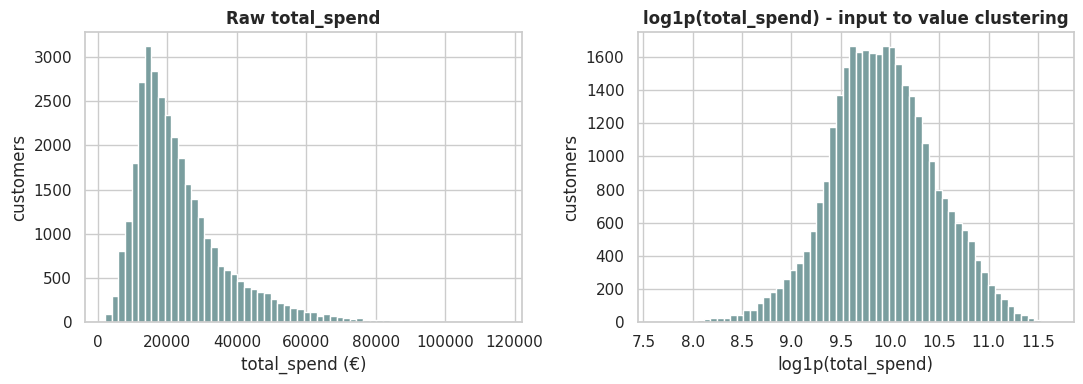

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

processed["total_spend"].hist(bins=60, ax=axes[0], color="#7a9e9f")
axes[0].set_title("Raw total_spend")
axes[0].set_xlabel("total_spend (€)")
axes[0].set_ylabel("customers")

processed["total_spend_log"].hist(bins=60, ax=axes[1], color="#7a9e9f")
axes[1].set_title("log1p(total_spend) - input to value clustering")
axes[1].set_xlabel("log1p(total_spend)")
axes[1].set_ylabel("customers")

plt.tight_layout()
plt.show()

The raw distribution is heavily right-skewed across a wide range; the log version is far more symmetric and well-behaved, which is what K-Means wants. This is exactly why `total_spend_log` (not raw `total_spend` or raw groceries) is what the value-perspective clustering ingests.

## 4. What the clustering actually sees

Two final views, both meant to make the input to clustering concrete rather than abstract.

### 4.1 Share distribution — the input to product-mix clustering

Each box shows one category's share-of-total-spend across all customers. Groceries dominates with a median around 0.65; every other category is squashed near zero (videogames and petfood medians under 0.02). This is exactly why we standardize before clustering: without scaling, groceries-share alone would drown out every other feature in the distance metric.

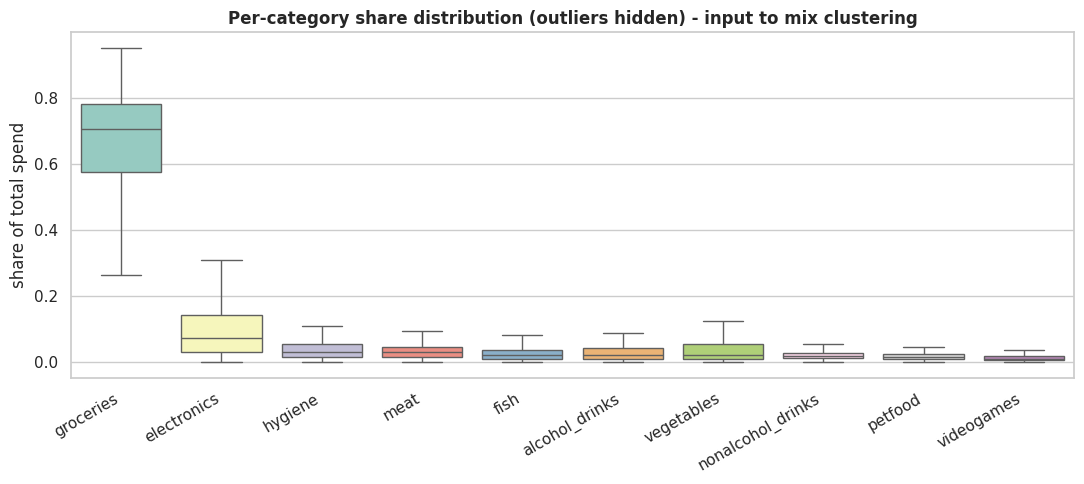

In [13]:
share_cols = [c for c in processed.columns if c.startswith("share_")]
share_long = processed[share_cols].melt(var_name="category", value_name="share")
share_long["category"] = share_long["category"].str.replace("share_", "")
# Order categories by median share for readability
order = (processed[share_cols].median()
         .sort_values(ascending=False).index.str.replace("share_", "").tolist())

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=share_long, x="category", y="share", order=order, ax=ax,
            hue="category", hue_order=order, palette="Set3", legend=False,
            showfliers=False)
ax.set_xlabel("")
ax.set_ylabel("share of total spend")
ax.set_title("Per-category share distribution (outliers hidden) - input to mix clustering")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 4.2 Pre-scaling feature ranges for the clustering inputs

The table below is the final summary of what each perspective receives, before `StandardScaler` is applied inside `clustering.py`. The wide range of scales — `lifetime_total_distinct_products` spans 0 to 600, several features are binary 0/1, and `total_spend_log` lives roughly in 7.5 to 11.7 — is exactly why each perspective gets its own scaler. The clustering perspectives never see these raw ranges; they see standardized z-scores.

In [14]:
clustering_feats = (
    cfg.VALUE_FEATURES + cfg.PRODUCT_MIX_FEATURES + cfg.DEMOGRAPHIC_FEATURES
)
seen = set()
clustering_feats = [f for f in clustering_feats if not (f in seen or seen.add(f))]

range_table = (processed[clustering_feats]
               .describe()
               .T[["min", "max", "mean", "std"]]
               .round(3))
range_table

,min,max,mean,std
total_spend_log,7.642,11.665,9.927,0.532
lifetime_total_distinct_products,0.000,600.000,148.915,105.923
distinct_stores_visited,1.000,10.000,3.166,1.666
tenure_years,0.000,33.000,10.749,4.887
promo_pct,0.000,1.000,0.325,0.271
share_groceries,0.000,0.951,0.651,0.186
share_electronics,0.000,0.793,0.114,0.127
share_vegetables,0.000,0.553,0.042,0.052
share_nonalcohol_drinks,0.000,0.200,0.023,0.016
share_alcohol_drinks,0.000,0.447,0.029,0.025


## 5. Run the full pipeline at once

`build_features` composes everything above into a single call.

**Fitted vs. deterministic steps.** Two steps depend on statistics of the data they see: median imputation and the 99th-percentile spend caps. Those belong to the *training* population and have to be frozen, exactly like a scaler — otherwise the same customer could land in a different segment depending on which file they were scored alongside. `build_features_with_params` returns both the features and those fitted statistics, and notebook 03 persists them next to the models so inference never re-derives a training statistic.

In [15]:
raw = pp.load_customer_info()
final, preproc_params = pp.build_features_with_params(raw)

print("Shape:", final.shape)
feature_cols = cfg.VALUE_FEATURES + cfg.PRODUCT_MIX_FEATURES + cfg.DEMOGRAPHIC_FEATURES
print("Any remaining nulls in feature columns?", final[feature_cols].isnull().sum().sum(), "total")

print("\nFitted preprocessing parameters (frozen for inference):")
print(f"  medians      : {preproc_params['medians']}")
print(f"  gender mode  : {preproc_params['gender_mode']}")
print(f"  spend caps   : {len(preproc_params['caps'])} columns, "
      f"e.g. electronics = {preproc_params['caps']['lifetime_spend_electronics']:.0f}")
print(f"  fitted on    : {preproc_params['n_fit_rows']:,} rows")

Shape: (33038, 49)
Any remaining nulls in feature columns? 0 total

Fitted preprocessing parameters (frozen for inference):
  medians      : {'distinct_stores_visited': 3.0, 'typical_hour': 12.0, 'percentage_of_products_bought_promotion': 0.2394492208095545, 'age': 54.86926762491444}
  gender mode  : female
  spend caps   : 9 columns, e.g. electronics = 16782
  fitted on    : 33,038 rows


## 6. Save the processed file

Two things happen here beyond the write itself.

**Identifiers are dropped.** `customer_name`, `customer_birthdate`, `latitude` and `longitude` are needed to *derive* features (age, degree) but nothing downstream reads them. No persisted artefact should carry per-person identifiers, so `drop_identifiers` strips them — along with the raw `loyalty_card_number`, now superseded by `has_loyalty_card`. `customer_id` stays because the basket join needs it.

**A shape check.** We assert the identifier columns really are gone before writing, so this cannot silently regress.

In [16]:
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

to_save = pp.drop_identifiers(final)
removed = sorted(set(final.columns) - set(to_save.columns))
print(f"Dropped before persisting: {removed}")

leaked = [c for c in cfg.IDENTIFIER_COLUMNS + cfg.SUPERSEDED_COLUMNS if c in to_save.columns]
assert not leaked, f"identifier columns would be persisted: {leaked}"
assert "customer_id" in to_save.columns, "customer_id must survive for the basket join"

to_save.to_parquet(cfg.PROCESSED_CUSTOMER_INFO)
print(f"Saved {cfg.PROCESSED_CUSTOMER_INFO.relative_to(cfg.PROJECT_ROOT)}  ({to_save.shape[0]:,} rows x {to_save.shape[1]} cols)")

Dropped before persisting: ['customer_birthdate', 'customer_name', 'latitude', 'longitude', 'loyalty_card_number']


Saved outputs/customer_info_processed.parquet  (33,038 rows x 44 cols)
